# **Entrega 2 — Transformações Lineares em Imagens Digitais**
### Álgebra Linear, Vetores e Geometria Analítica — Grupo 8 · Radonix

Este notebook gera um arquivo Excel colorido para **cada transformação linear**,
no mesmo formato do Entregável 1 (células coloridas com o valor numérico oculto).

---
## 0. Instalação e Importações

In [ ]:
!pip install xlsxwriter -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
from PIL import Image
import pandas as pd
from google.colab import files
import io
import xlsxwriter
from scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt


---
## 1. Carregamento da Imagem

A imagem sera redimensionada para **200 x 200 pixels**, igual ao Entregavel 1.


Selecione a imagem (PNG ou JPG):


Saving img_edicao_PI.jpg to img_edicao_PI.jpg
Imagem carregada: img_edicao_PI.jpg
Shape RGB:  (200, 200, 3)
Shape Gray: (200, 200)


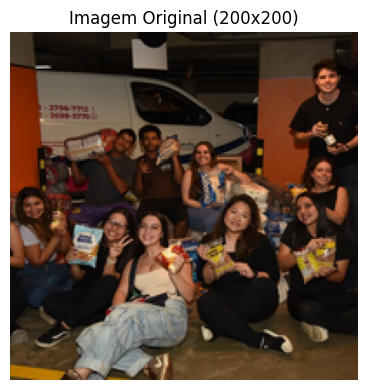

In [ ]:
print('Selecione a imagem (PNG ou JPG):')
uploaded = files.upload()

nome_arquivo = next(iter(uploaded))
image_bytes = uploaded[nome_arquivo]
img_pil = Image.open(io.BytesIO(image_bytes))

# Dois fluxos: RGB (cores) e L (grayscale / valores numericos)
img_rgb  = img_pil.convert('RGB').resize((200, 200), Image.LANCZOS)
img_gray = img_pil.convert('L').resize((200, 200), Image.LANCZOS)

# Matrizes base
mat_cores    = np.array(img_rgb)    # shape (200, 200, 3)
mat_numeros  = np.array(img_gray)   # shape (200, 200)

print(f'Imagem carregada: {nome_arquivo}')
print(f'Shape RGB:  {mat_cores.shape}')
print(f'Shape Gray: {mat_numeros.shape}')

plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.title('Imagem Original (200x200)')
plt.axis('off')
plt.tight_layout()
plt.show()


---
## 2. Funcoes Auxiliares

- **`aplicar_transformacao(M, mat_rgb, mat_gray)`** — aplica a matriz 2x2 via mapeamento inverso e retorna as duas matrizes transformadas (RGB e grayscale).
- **`salvar_excel(mat_rgb, mat_gray, nome)`** — gera o arquivo `.xlsx` colorido, identico ao padrao do Entregavel 1.


In [ ]:
H, W = 200, 200
cx, cy = W / 2.0, H / 2.0

cols_grid, rows_grid = np.meshgrid(np.arange(W), np.arange(H))
coords_dest = np.stack([
    cols_grid.ravel() - cx,
    rows_grid.ravel() - cy
])  # shape (2, 40000)


def aplicar_transformacao(M, rgb, gray):
    det = np.linalg.det(M)
    if abs(det) < 1e-10:
        raise ValueError('Matriz singular: det = 0. Use mapeamento direto.')
    M_inv = np.linalg.inv(M)
    src = M_inv @ coords_dest
    src_row = src[1] + cy
    src_col = src[0] + cx
    rgb_t = np.zeros_like(rgb)
    for c in range(3):
        rgb_t[..., c] = map_coordinates(
            rgb[..., c].astype(float),
            [src_row.reshape(H, W), src_col.reshape(H, W)],
            order=1, mode='constant', cval=0
        ).astype(np.uint8)
    gray_t = map_coordinates(
        gray.astype(float),
        [src_row.reshape(H, W), src_col.reshape(H, W)],
        order=1, mode='constant', cval=0
    ).astype(np.uint8)
    return rgb_t, gray_t


def salvar_excel(mat_rgb, mat_gray, nome_saida):
    workbook  = xlsxwriter.Workbook(nome_saida)
    worksheet = workbook.add_worksheet('Mapa de Liderancas')
    worksheet.set_column(0, 199, 2.5)
    formatos_cache = {}
    for r in range(200):
        worksheet.set_row(r, 15)
        for c in range(200):
            rgb = mat_rgb[r, c]
            hex_color = '#{:02x}{:02x}{:02x}'.format(int(rgb[0]), int(rgb[1]), int(rgb[2]))
            valor_id  = int(mat_gray[r, c])
            if hex_color not in formatos_cache:
                formatos_cache[hex_color] = workbook.add_format({
                    'bg_color':   hex_color,
                    'num_format': ';;;'
                })
            worksheet.write(r, c, valor_id, formatos_cache[hex_color])
    workbook.close()
    print(f'  Salvo: {nome_saida}')


print('Funcoes definidas.')


Funcoes definidas.


---
## 3. Excel da Imagem Original

Gera o mesmo arquivo do Entregavel 1 como referencia de comparacao.


In [ ]:
print('Gerando Excel da imagem original...')
salvar_excel(mat_cores, mat_numeros, 'T0_original.xlsx')
print('Pronto!')


Gerando Excel da imagem original...
  Salvo: T0_original.xlsx
Pronto!


---
## 4. Transformacao 1 — Escalonamento (Scaling)

$$M_{\text{escala}} = \begin{pmatrix} s_x & 0 \\ 0 & s_y \end{pmatrix}$$

- `sx > 1` expande horizontalmente; `sx < 1` contrai.
- `sy > 1` expande verticalmente; `sy < 1` contrai.
- `det(M) = sx * sy`. Preserva o espaco enquanto **det != 0**.


Matriz de Escalonamento:
[[1.5  0.  ]
 [0.   0.75]]
det(M) = 1.1250


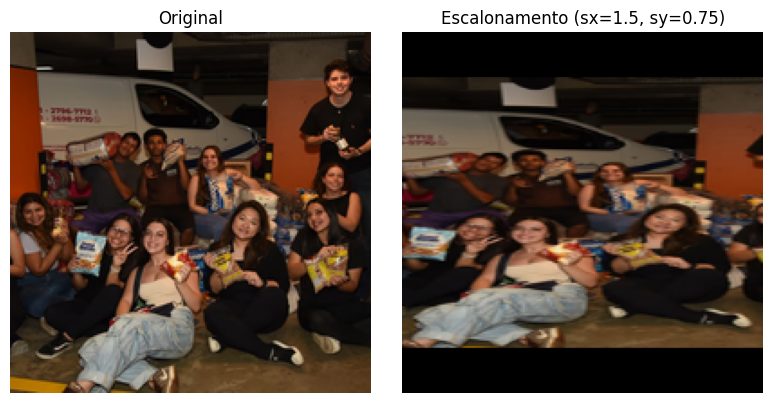

Gerando Excel do Escalonamento...
  Salvo: T1_escalonamento.xlsx


In [ ]:
sx = 1.5   # fator horizontal (tente: 0.5, 2.0, -1 para espelhar)
sy = 0.75  # fator vertical

M_escala = np.array([
    [sx,  0],
    [ 0, sy]
], dtype=float)

print('Matriz de Escalonamento:')
print(M_escala)
print(f'det(M) = {np.linalg.det(M_escala):.4f}')

rgb_esc, gray_esc = aplicar_transformacao(M_escala, mat_cores, mat_numeros)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mat_cores);  axes[0].set_title('Original');       axes[0].axis('off')
axes[1].imshow(rgb_esc);    axes[1].set_title(f'Escalonamento (sx={sx}, sy={sy})'); axes[1].axis('off')
plt.tight_layout(); plt.show()

print('Gerando Excel do Escalonamento...')
salvar_excel(rgb_esc, gray_esc, 'T1_escalonamento.xlsx')


---
## 5. Transformacao 2 — Cisalhamento (Shear)

$$M_{\text{cis}} = \begin{pmatrix} 1 & k_x \\ k_y & 1 \end{pmatrix}$$

- `kx != 0` inclina horizontalmente proporcional a posicao y.
- `ky != 0` inclina verticalmente proporcional a posicao x.
- `det(M) = 1 - kx*ky`.


Matriz de Cisalhamento:
[[1.  0.4]
 [0.  1. ]]
det(M) = 1.0000


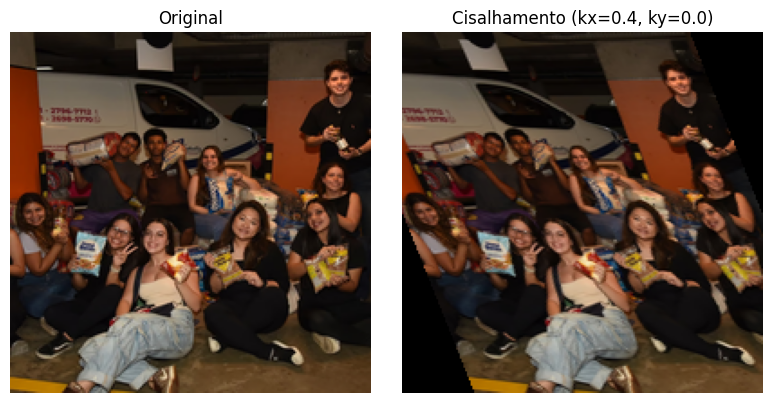

Gerando Excel do Cisalhamento...
  Salvo: T2_cisalhamento.xlsx


In [ ]:
kx = 0.4   # cisalhamento horizontal (tente: 0.2, 0.8, -0.4)
ky = 0.0   # cisalhamento vertical

M_cis = np.array([
    [1,  kx],
    [ky,  1]
], dtype=float)

print('Matriz de Cisalhamento:')
print(M_cis)
print(f'det(M) = {np.linalg.det(M_cis):.4f}')

rgb_cis, gray_cis = aplicar_transformacao(M_cis, mat_cores, mat_numeros)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mat_cores);  axes[0].set_title('Original');                 axes[0].axis('off')
axes[1].imshow(rgb_cis);    axes[1].set_title(f'Cisalhamento (kx={kx}, ky={ky})'); axes[1].axis('off')
plt.tight_layout(); plt.show()

print('Gerando Excel do Cisalhamento...')
salvar_excel(rgb_cis, gray_cis, 'T2_cisalhamento.xlsx')


---
## 6. Transformacao 3 — Rotacao

$$M_{\text{rot}}(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$$

- Transformacao **ortogonal**: preserva distancias e angulos.
- `det(M) = 1` sempre — nunca colapsa o espaco.
- Inversa = transposta: `M_inv = M^T`.


Matriz de Rotacao:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]
det(M) = 1.0000


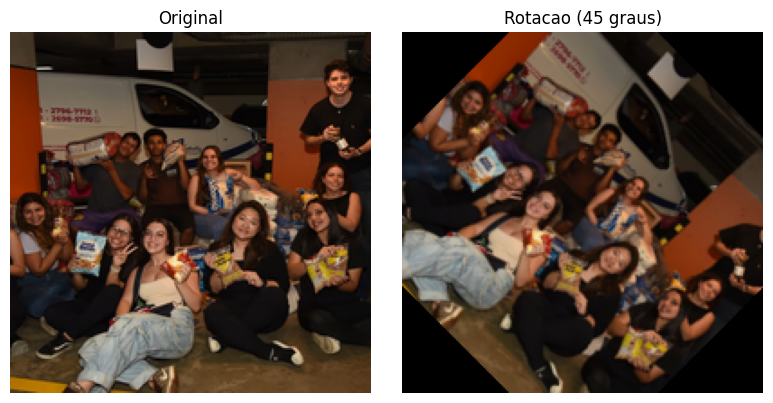

Gerando Excel da Rotacao...
  Salvo: T3_rotacao.xlsx


In [ ]:
angulo_graus = 45   # tente: 30, 90, 180, 270

theta = np.radians(angulo_graus)
M_rot = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

print('Matriz de Rotacao:')
print(np.round(M_rot, 4))
print(f'det(M) = {np.linalg.det(M_rot):.4f}')

rgb_rot, gray_rot = aplicar_transformacao(M_rot, mat_cores, mat_numeros)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mat_cores);  axes[0].set_title('Original');                    axes[0].axis('off')
axes[1].imshow(rgb_rot);    axes[1].set_title(f'Rotacao ({angulo_graus} graus)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

print('Gerando Excel da Rotacao...')
salvar_excel(rgb_rot, gray_rot, 'T3_rotacao.xlsx')


---
## 7. Transformacao 4 — Composicao (Rotacao * Escala * Cisalhamento)

$$M_{\text{comp}} = M_{\text{rot}} \cdot M_{\text{escala}} \cdot M_{\text{cis}}$$

A transformacao mais a **direita** e aplicada **primeiro**.  
O determinante da composicao e o produto dos determinantes individuais.


Matriz Composta:
[[ 1.0607 -0.1061]
 [ 1.0607  0.9546]]
det(M_comp) = 1.1250
  = det_rot(1.000) x det_escala(1.125) x det_cis(1.000)


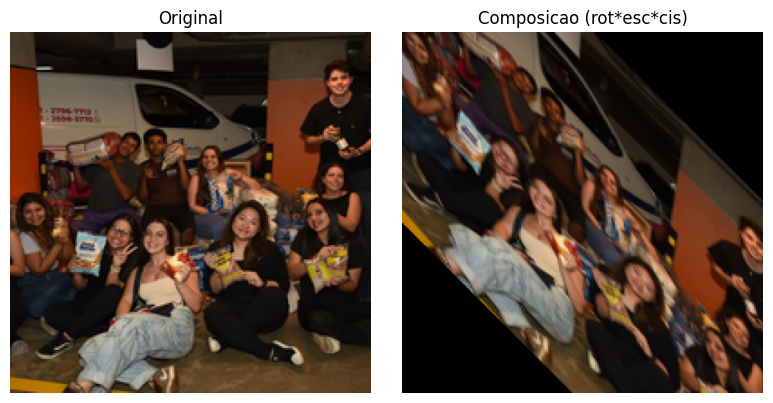

Gerando Excel da Composicao...
  Salvo: T4_composicao.xlsx


In [ ]:
M_comp = M_rot @ M_escala @ M_cis

print('Matriz Composta:')
print(np.round(M_comp, 4))
print(f'det(M_comp) = {np.linalg.det(M_comp):.4f}')
print(f'  = det_rot({np.linalg.det(M_rot):.3f}) x det_escala({np.linalg.det(M_escala):.3f}) x det_cis({np.linalg.det(M_cis):.3f})')

rgb_comp, gray_comp = aplicar_transformacao(M_comp, mat_cores, mat_numeros)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mat_cores);  axes[0].set_title('Original');              axes[0].axis('off')
axes[1].imshow(rgb_comp);   axes[1].set_title('Composicao (rot*esc*cis)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

print('Gerando Excel da Composicao...')
salvar_excel(rgb_comp, gray_comp, 'T4_composicao.xlsx')


---
## 8. Transformacao 5 — Colapso Dimensional (Projecao)

$$M_{\text{proj}} = \begin{pmatrix} 1 & 0 \\ 0 & 0 \end{pmatrix} \quad \Rightarrow \quad \det = 0$$

Quando `det = 0` a matriz e **singular**: nao existe inversa.  
Usamos mapeamento **direto** (origem -> destino) para visualizar a perda de informacao.  
Toda a coordenada Y e zerada — a imagem colapsa para uma unica linha horizontal.


Matriz de Projecao (colapso dimensional):
[[1. 0.]
 [0. 0.]]
det(M_proj) = 0.0000  --> SINGULAR (sem inversa)


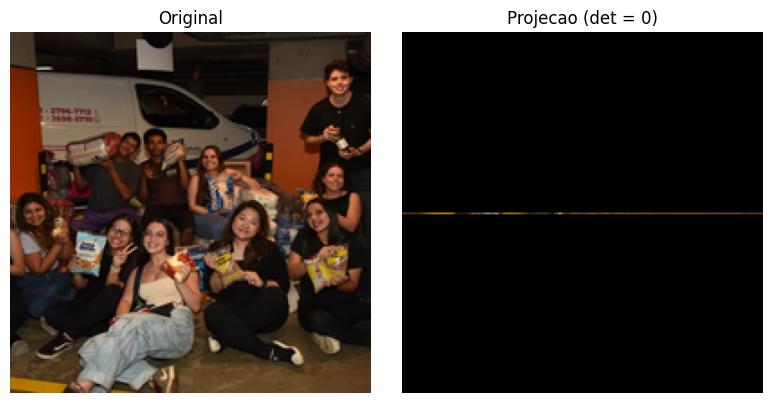

Gerando Excel da Projecao (Colapso Dimensional)...
  Salvo: T5_colapso_dimensional.xlsx


In [ ]:
M_proj = np.array([
    [1, 0],
    [0, 0]
], dtype=float)

print('Matriz de Projecao (colapso dimensional):')
print(M_proj)
print(f'det(M_proj) = {np.linalg.det(M_proj):.4f}  --> SINGULAR (sem inversa)')

# Mapeamento direto (origem -> destino)
rgb_proj  = np.zeros((H, W, 3), dtype=np.uint8)
gray_proj = np.zeros((H, W),    dtype=np.uint8)

for r in range(H):
    for c in range(W):
        xc, yc = c - cx, r - cy
        ponto  = M_proj @ np.array([xc, yc])
        dc = int(np.round(ponto[0] + cx))
        dr = int(np.round(ponto[1] + cy))
        if 0 <= dr < H and 0 <= dc < W:
            rgb_proj[dr, dc]  = mat_cores[r, c]
            gray_proj[dr, dc] = mat_numeros[r, c]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mat_cores);  axes[0].set_title('Original');             axes[0].axis('off')
axes[1].imshow(rgb_proj);   axes[1].set_title('Projecao (det = 0)');   axes[1].axis('off')
plt.tight_layout(); plt.show()

print('Gerando Excel da Projecao (Colapso Dimensional)...')
salvar_excel(rgb_proj, gray_proj, 'T5_colapso_dimensional.xlsx')


---
## 9. Download de Todos os Arquivos Excel


In [ ]:
arquivos_excel = [
    'T0_original.xlsx',
    'T1_escalonamento.xlsx',
    'T2_cisalhamento.xlsx',
    'T3_rotacao.xlsx',
    'T4_composicao.xlsx',
    'T5_colapso_dimensional.xlsx',
]

for arq in arquivos_excel:
    try:
        files.download(arq)
        print(f'Download iniciado: {arq}')
    except Exception as e:
        print(f'Erro ao baixar {arq}: {e}')

print('Concluido! Verifique os downloads no seu navegador.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download iniciado: T0_original.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Download iniciado: T4_composicao.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download iniciado: T5_colapso_dimensional.xlsx
Concluido! Verifique os downloads no seu navegador.
